# 신용카드 채무불이행 고객 예측 -

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [ ]:
#!pip install xlrd --break-system-packages


In [1]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

# xls 읽기
df = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
df.to_csv('./data/UCI_Credit_Card.csv', index=False)
print(df.shape)

# df = pd.read_csv('./data/UCI_Credit_Card.csv')
card_df = df.drop('ID', axis=1)
card_df.head(3)

(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


# Default 예측 모델링 프로세스 (Recall Focus)
## 1) 목표/평가지표 확정
비즈니스 목표: 부실 가능 고객을 놓치지 않기
1순위 지표: Recall
보조 지표: Precision, F1, PR-AUC
운영 기준 예시:
Recall 최소 기준(예: 0.80 또는 0.85) 먼저 만족
그 조건에서 Precision 최대화

# 기초 EDA (분할 후 Train 기준)
타깃 불균형 정도 확인

결측치 비율/패턴 확인

변수 타입 점검 (수치형/범주형)

이상치 후보 확인

목적:

전처리 전략 근거 확보

Recall 저해 요인 사전 파악

In [2]:
# 1단계: 기본 현황 파악
print("=== Shape ===")
print(card_df.shape)

print("\n=== 데이터 타입 ===")
print(card_df.dtypes)

print("\n=== 결측치 확인 ===")
print(card_df.isnull().sum())

=== Shape ===
(30000, 24)

=== 데이터 타입 ===
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

=== 결측치 확인 ===
LIMIT_BAL                     0
SEX                           0


In [3]:
# 기초 통계량
card_df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


1단계 결과 요약

✅ 결측치 없음 — 모든 컬럼 30,000개 완전
✅ 모든 컬럼 int64 — 별도 타입 변환 불필요

주목할 이상값들:

EDUCATION: min=0, max=6 → 공식 코드북엔 1~4만 정의 (0, 5, 6은 이상값)
MARRIAGE: min=0, max=3 → 공식 코드북엔 1~3만 정의 (0은 이상값)
BILL_AMT 시리즈: 음수값 존재 (예: min=-170,000) → 과납/환급 케이스
PAY_AMT 시리즈: max가 매우 큼 (1.6M) → 극단적 이상값 가능성

In [12]:
card_df = card_df.rename(columns={'default payment next month': 'default'})
card_df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='str')

In [14]:
# 2단계: 타겟(default) 분포 확인
print("=== Default 클래스 분포 ===")
print(card_df['default'].value_counts())
print()
print("=== 비율 ===")
print(card_df['default'].value_counts(normalize=True).round(3))

=== Default 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

=== 비율 ===
default
0    0.779
1    0.221
Name: proportion, dtype: float64


2단계 결과 요약

정상(0): 23,364명 (77.9%)
채무불이행(1): 6,636명 (22.1%)
약 3.5:1 불균형 → 나중에 전처리 시 대응 필요 (SMOTE 또는 class_weight 등)

In [15]:
# 3단계: 범주형 피처 값 분포
print("=== EDUCATION 값 분포 ===")
print(card_df['EDUCATION'].value_counts().sort_index())

print("\n=== MARRIAGE 값 분포 ===")
print(card_df['MARRIAGE'].value_counts().sort_index())

print("\n=== SEX 값 분포 ===")
print(card_df['SEX'].value_counts().sort_index())

=== EDUCATION 값 분포 ===
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

=== MARRIAGE 값 분포 ===
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

=== SEX 값 분포 ===
SEX
1    11888
2    18112
Name: count, dtype: int64


In [16]:
# PAY_0 ~ PAY_6 고유값 확인
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
for col in pay_cols:
    print(f"{col}: {sorted(card_df[col].unique())}")

PAY_0: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


3단계 결과 요약범주형 이상값:

EDUCATION: 0(14개), 5(280개), 6(51개) → 총 345개 이상값 (코드북 정의 외)
MARRIAGE: 0(54개) → 이상값
SEX: 1/2만 존재 → 정상
PAY 시리즈:

-2, -1, 0 모두 존재 → 정상 (각각 잔액없음/정상결제/최소결제 의미)
1~8: 연체 개월 수 → 정상

In [17]:
# 4단계: 피처별 Default 비율
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in cat_cols:
    print(f"=== {col}별 Default 비율 ===")
    print(card_df.groupby(col)['default'].mean().round(3))
    print()

=== SEX별 Default 비율 ===
SEX
1    0.242
2    0.208
Name: default, dtype: float64

=== EDUCATION별 Default 비율 ===
EDUCATION
0    0.000
1    0.192
2    0.237
3    0.252
4    0.057
5    0.064
6    0.157
Name: default, dtype: float64

=== MARRIAGE별 Default 비율 ===
MARRIAGE
0    0.093
1    0.235
2    0.209
3    0.260
Name: default, dtype: float64



In [18]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
for col in pay_cols:
    print(f"=== {col}별 Default 비율 ===")
    print(card_df.groupby(col)['default'].mean().round(3))
    print()

=== PAY_0별 Default 비율 ===
PAY_0
-2    0.132
-1    0.168
 0    0.128
 1    0.339
 2    0.691
 3    0.758
 4    0.684
 5    0.500
 6    0.545
 7    0.778
 8    0.579
Name: default, dtype: float64

=== PAY_2별 Default 비율 ===
PAY_2
-2    0.183
-1    0.160
 0    0.159
 1    0.179
 2    0.556
 3    0.617
 4    0.505
 5    0.600
 6    0.750
 7    0.600
 8    0.000
Name: default, dtype: float64

=== PAY_3별 Default 비율 ===
PAY_3
-2    0.185
-1    0.156
 0    0.175
 1    0.250
 2    0.516
 3    0.575
 4    0.579
 5    0.571
 6    0.609
 7    0.815
 8    0.667
Name: default, dtype: float64

=== PAY_4별 Default 비율 ===
PAY_4
-2    0.193
-1    0.159
 0    0.183
 1    0.500
 2    0.523
 3    0.611
 4    0.667
 5    0.514
 6    0.400
 7    0.828
 8    0.500
Name: default, dtype: float64

=== PAY_5별 Default 비율 ===
PAY_5
-2    0.197
-1    0.162
 0    0.189
 2    0.542
 3    0.635
 4    0.607
 5    0.588
 6    0.750
 7    0.828
 8    1.000
Name: default, dtype: float64

=== PAY_6별 Default 비율 ===
PAY_6
-2   

In [19]:
# 수치형 피처와 default 상관관계
corr = card_df.corr()['default'].drop('default').sort_values(ascending=False)
print("=== default와 상관관계 (상위/하위) ===")
print(corr)

=== default와 상관관계 (상위/하위) ===
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
MARRIAGE    -0.024339
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: default, dtype: float64


4단계 결과 요약
범주형 피처:

SEX: 남성(1) 24.2% > 여성(2) 20.8% → 차이 미미
EDUCATION: 이상값(0,4,5,6)은 샘플 수 적고 비율도 튀어있음 → 전처리 필요
MARRIAGE: 이상값(0)은 9.3%로 낮음 → 전처리 필요

PAY 시리즈 (핵심 발견!):

연체 1개월(1)만 돼도 Default 비율 급등 (PAY_0 기준: 0→13% → 1→34% → 2→69%)
PAY_0이 가장 강력한 예측 피처 (상관관계 0.325로 1위)

상관관계 전체:

상위: PAY_0~PAY_6 (연체 관련) → 예측력 높음
하위: BILL_AMT 시리즈 → 상관관계 거의 없음
LIMIT_BAL (-0.154) → 한도 높을수록 Default 낮음 (합리적)

EDA 종합 결론 → 전처리 시 할 일들:

EDUCATION 이상값(0,5,6) → 처리 방안 필요
MARRIAGE 이상값(0) → 처리 방안 필요
클래스 불균형 (78:22) → 모델링 시 대응 필요
BILL_AMT 음수값 → 처리 방안 검토

In [20]:
# EDUCATION = 0 인 데이터 확인
print("=== EDUCATION = 0 데이터 ===")
print(f"행 수: {len(card_df[card_df['EDUCATION'] == 0])}")
print(card_df[card_df['EDUCATION'] == 0])

=== EDUCATION = 0 데이터 ===
행 수: 14
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
3769      290000    2          0         2   38      1     -1     -1     -1   
5945      270000    1          0         2   39      1     -1     -1     -1   
6876      360000    1          0         2   30      0      0     -1      0   
14631     350000    2          0         2   53     -1     -1     -1     -1   
15107     210000    1          0         2   45     -2     -2     -2     -2   
16881     100000    1          0         2   37      0      0     -2     -2   
16896     200000    1          0         2   40      1     -2     -1     -1   
17414     230000    2          0         2   47     -1     -1     -1      2   
19920      50000    2          0         1   40      0      0      0      0   
20030     200000    2          0         2   30     -1     -1      2     -1   
23234     220000    2          0         1   35     -2     -2     -2     -2   
24137     150000  

In [21]:
# MARRIAGE = 0 인 데이터 확인
print("=== MARRIAGE = 0 데이터 ===")
print(f"행 수: {len(card_df[card_df['MARRIAGE'] == 0])}")
print(card_df[card_df['MARRIAGE'] == 0])

=== MARRIAGE = 0 데이터 ===
행 수: 54
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
218       110000    2          3         0   31      0      0      0      0   
809       160000    2          2         0   37      0      0      0      0   
820       200000    2          3         0   51     -1     -1     -1     -1   
1019      180000    2          3         0   45     -1     -1     -2     -2   
1443      200000    1          3         0   51     -1     -1     -1     -1   
2146      150000    2          3         0   55     -1     -1     -1     -1   
2554      220000    2          1         0   33     -1     -1     -1     -1   
3056      200000    1          3         0   36     -2     -2     -2     -2   
4470       70000    1          3         0   35      2      2      2      2   
5005       90000    2          3         0   24     -2     -2     -2     -1   
5345       50000    2          2         0   28      1      2      0      0   
6389       10000   

In [22]:
# EDUCATION = 5, 6 인 데이터 확인
print("=== EDUCATION = 5, 6 데이터 (unknown) ===")
print(f"행 수: {len(card_df[card_df['EDUCATION'].isin([5, 6])])}")
print(card_df[card_df['EDUCATION'].isin([5, 6])])

=== EDUCATION = 5, 6 데이터 (unknown) ===
행 수: 331
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
47        150000    2          5         2   46      0      0     -1      0   
69         20000    1          5         2   22      2      0      0      0   
385       410000    2          5         1   42      0      0      0      0   
502       230000    2          6         2   46      0      0      0      0   
504        30000    1          6         1   53     -2     -2     -2     -2   
...          ...  ...        ...       ...  ...    ...    ...    ...    ...   
29811      50000    1          5         2   46      0      0      0     -1   
29836     180000    1          6         1   34     -2     -2     -2     -2   
29839     150000    1          5         1   36      0      0      0      0   
29920      50000    1          5         1   45      2      0      0      0   
29966     150000    1          5         2   31      2      0      0      0   

   

In [23]:
# EDUCATION 값별 Default 비율 + 샘플 수
print("=== EDUCATION별 Default 비율 ===")
edu_stats = card_df.groupby('EDUCATION')['default'].agg(['mean', 'count'])
edu_stats.columns = ['default_rate', 'count']
print(edu_stats.round(3))

=== EDUCATION별 Default 비율 ===
           default_rate  count
EDUCATION                     
0                 0.000     14
1                 0.192  10585
2                 0.237  14030
3                 0.252   4917
4                 0.057    123
5                 0.064    280
6                 0.157     51


In [24]:
# MARRIAGE 값별 Default 비율 + 샘플 수
print("=== MARRIAGE별 Default 비율 ===")
mar_stats = card_df.groupby('MARRIAGE')['default'].agg(['mean', 'count'])
mar_stats.columns = ['default_rate', 'count']
print(mar_stats.round(3))

=== MARRIAGE별 Default 비율 ===
          default_rate  count
MARRIAGE                     
0                0.093     54
1                0.235  13659
2                0.209  15964
3                0.260    323


In [25]:
# EDUCATION: 0, 5, 6 → 4로 통합
card_df['EDUCATION'] = card_df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: 0 → 3으로 통합
card_df['MARRIAGE'] = card_df['MARRIAGE'].replace({0: 3})

# 확인
print("=== EDUCATION 처리 후 ===")
print(card_df['EDUCATION'].value_counts().sort_index())

print("\n=== MARRIAGE 처리 후 ===")
print(card_df['MARRIAGE'].value_counts().sort_index())

=== EDUCATION 처리 후 ===
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

=== MARRIAGE 처리 후 ===
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [26]:
# 타겟/피처 분리
y_target = card_df['default']
X_features = card_df.drop('default', axis=1)

# train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target  # 클래스 비율 유지
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train 비율:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"y_test 비율:\n{y_test.value_counts(normalize=True).round(3)}")

X_train: (24000, 23), X_test: (6000, 23)
y_train 비율:
default
0    0.779
1    0.221
Name: proportion, dtype: float64
y_test 비율:
default
0    0.779
1    0.221
Name: proportion, dtype: float64


In [27]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_clf_eval(y_test, y_pred, y_pred_proba, model_name='Model'):
    # 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    print(f"=== [{model_name}] 성능 평가 ===")
    print(f"혼동행렬:")
    print(f"  TN={cm[0,0]:>6}  FP={cm[0,1]:>6}")
    print(f"  FN={cm[1,0]:>6}  TP={cm[1,1]:>6}")
    print()
    
    # 지표 계산
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_proba)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    # 출력 (Recall 강조)
    print(f"  ★ Recall   : {recall:.4f}")
    print(f"     F1      : {f1:.4f}")
    print(f"     ROC-AUC : {roc_auc:.4f}")
    print(f"     Accuracy: {accuracy:.4f}")
    print(f"     Precision:{precision:.4f}")
    
    # 비교 테이블용 dict 반환
    return {
        'Model'    : model_name,
        'Recall'   : round(recall, 4),
        'F1'       : round(f1, 4),
        'ROC-AUC'  : round(roc_auc, 4),
        'Accuracy' : round(accuracy, 4),
        'Precision': round(precision, 4)
    }

실험 1: 기본 모델 (스케일링 X, 불균형처리 X)
  - Logistic Regression
  - Random Forest
  - LightGBM

실험 2: 스케일링 추가
  - Logistic Regression + Scaling
  - Random Forest + Scaling
  - LightGBM + Scaling

실험 3: 스케일링 + 불균형처리 추가
  - Logistic Regression + Scaling + SMOTE
  - Random Forest + Scaling + SMOTE
  - LightGBM + Scaling + SMOTE

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# 모델 정의
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'LightGBM'          : LGBMClassifier(n_estimators=100, random_state=42)
}

# 결과 누적 리스트
results = []

# 학습 및 평가
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    result = get_clf_eval(y_test, y_pred, y_pred_proba, model_name=f'{model_name}_base')
    results.append(result)
    print()

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== [LogisticRegression_base] 성능 평가 ===
혼동행렬:
  TN=  4529  FP=   144
  FN=  1044  TP=   283

  ★ Recall   : 0.2133
     F1      : 0.3227
     ROC-AUC : 0.6841
     Accuracy: 0.8020
     Precision:0.6628

=== [RandomForest_base] 성능 평가 ===
혼동행렬:
  TN=  4408  FP=   265
  FN=   850  TP=   477

  ★ Recall   : 0.3595
     F1      : 0.4611
     ROC-AUC : 0.7572
     Accuracy: 0.8142
     Precision:0.6429

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002393 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3262
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
=== [LightGBM_base] 성능 평가 ===
혼동행렬:
  TN=  4432  FP=   241
  FN=   853  TP=   474

  ★ Recall   : 0.3572


스케일링

In [29]:
from sklearn.preprocessing import StandardScaler

# 원본 데이터 복사
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 스케일링 적용 (train 기준으로 fit, test는 transform만)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_scaled)
X_test_scaled = scaler.transform(X_test_scaled)

In [30]:
# 모델 정의
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'LightGBM'          : LGBMClassifier(n_estimators=100, random_state=42)
}

# 학습 및 평가
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred       = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    result = get_clf_eval(y_test, y_pred, y_pred_proba, model_name=f'{model_name}_scaled')
    results.append(result)
    print()

=== [LogisticRegression_scaled] 성능 평가 ===
혼동행렬:
  TN=  4529  FP=   144
  FN=  1006  TP=   321

  ★ Recall   : 0.2419
     F1      : 0.3583
     ROC-AUC : 0.7079
     Accuracy: 0.8083
     Precision:0.6903

=== [RandomForest_scaled] 성능 평가 ===
혼동행렬:
  TN=  4406  FP=   267
  FN=   850  TP=   477

  ★ Recall   : 0.3595
     F1      : 0.4606
     ROC-AUC : 0.7577
     Accuracy: 0.8138
     Precision:0.6411

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3268
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
=== [LightGBM_scaled] 성능 평가 ===
혼동행렬:
  TN=  4429  FP=   244
  FN=   851  TP=   476

  ★ Recall   : 0

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [31]:
# 실험 1 + 2 비교 테이블
pd.DataFrame(results).set_index('Model')

,Recall,F1,ROC-AUC,Accuracy,Precision
Model,,,,,
LogisticRegression_base,0.2133,0.3227,0.6841,0.8020,0.6628
RandomForest_base,0.3595,0.4611,0.7572,0.8142,0.6429
LightGBM_base,0.3572,0.4643,0.7756,0.8177,0.6629
LogisticRegression_scaled,0.2419,0.3583,0.7079,0.8083,0.6903
RandomForest_scaled,0.3595,0.4606,0.7577,0.8138,0.6411
LightGBM_scaled,0.3587,0.4651,0.7736,0.8175,0.6611


In [32]:
# 중복 제거
results_df = pd.DataFrame(results).drop_duplicates()
results = results_df.to_dict('records')

# 확인
pd.DataFrame(results).set_index('Model')

,Recall,F1,ROC-AUC,Accuracy,Precision
Model,,,,,
LogisticRegression_base,0.2133,0.3227,0.6841,0.8020,0.6628
RandomForest_base,0.3595,0.4611,0.7572,0.8142,0.6429
LightGBM_base,0.3572,0.4643,0.7756,0.8177,0.6629
LogisticRegression_scaled,0.2419,0.3583,0.7079,0.8083,0.6903
RandomForest_scaled,0.3595,0.4606,0.7577,0.8138,0.6411
LightGBM_scaled,0.3587,0.4651,0.7736,0.8175,0.6611


SMOTE

In [33]:
from imblearn.over_sampling import SMOTE

# SMOTE 적용 (train 데이터만!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE 전 y_train 분포:\n{y_train.value_counts()}")
print(f"\nSMOTE 후 y_train 분포:\n{pd.Series(y_train_smote).value_counts()}")

SMOTE 전 y_train 분포:
default
0    18691
1     5309
Name: count, dtype: int64

SMOTE 후 y_train 분포:
default
0    18691
1    18691
Name: count, dtype: int64


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [34]:
# 모델 정의
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'LightGBM'          : LGBMClassifier(n_estimators=100, random_state=42)
}

# 학습 및 평가
for model_name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred       = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    result = get_clf_eval(y_test, y_pred, y_pred_proba, model_name=f'{model_name}_smote')
    results.append(result)
    print()

=== [LogisticRegression_smote] 성능 평가 ===
혼동행렬:
  TN=  3201  FP=  1472
  FN=   494  TP=   833

  ★ Recall   : 0.6277
     F1      : 0.4587
     ROC-AUC : 0.7108
     Accuracy: 0.6723
     Precision:0.3614

=== [RandomForest_smote] 성능 평가 ===
혼동행렬:
  TN=  4156  FP=   517
  FN=   704  TP=   623

  ★ Recall   : 0.4695
     F1      : 0.5051
     ROC-AUC : 0.7474
     Accuracy: 0.7965
     Precision:0.5465

[LightGBM] [Info] Number of positive: 18691, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5714
[LightGBM] [Info] Number of data points in the train set: 37382, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
=== [LightGBM_smote] 성능 평가 ===
혼동행렬:
  TN=  4288  FP=   385
  FN=   762  TP=   565

  ★ Recall   : 0.4258
     F1      : 0.4963
     ROC-AUC : 0.7694
     Ac

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
# 전체 비교 테이블
pd.DataFrame(results).set_index('Model')

,Recall,F1,ROC-AUC,Accuracy,Precision
Model,,,,,
LogisticRegression_base,0.2133,0.3227,0.6841,0.8020,0.6628
RandomForest_base,0.3595,0.4611,0.7572,0.8142,0.6429
LightGBM_base,0.3572,0.4643,0.7756,0.8177,0.6629
LogisticRegression_scaled,0.2419,0.3583,0.7079,0.8083,0.6903
RandomForest_scaled,0.3595,0.4606,0.7577,0.8138,0.6411
LightGBM_scaled,0.3587,0.4651,0.7736,0.8175,0.6611
LogisticRegression_smote,0.6277,0.4587,0.7108,0.6723,0.3614
RandomForest_smote,0.4695,0.5051,0.7474,0.7965,0.5465
LightGBM_smote,0.4258,0.4963,0.7694,0.8088,0.5947


전체 실험 결과 분석

| 모델 | base | scaled | smote | 변화 |
|---|---|---|---|---|
| LogisticRegression | 0.2133 | 0.2419 | **0.6277** | 🔥 급등 |
| RandomForest | 0.3595 | 0.3595 | **0.4695** | ✅ 개선 |
| LightGBM | 0.3572 | 0.3587 | **0.4258** | ✅ 개선 |

핵심 관찰:

SMOTE 적용 후 모든 모델 Recall 크게 향상 → 불균형 처리 효과 확실
LR_smote: Recall 0.63으로 가장 높지만 Precision 0.36으로 낮음 → FP 많이 발생
RF_smote: Recall/F1/Accuracy 균형 가장 좋음
LightGBM_smote: ROC-AUC 0.7694로 가장 높음, Precision도 RF보다 높음


트레이드오프 정리:

Recall 최우선 → LR_smote (0.6277)
Recall + 균형 → RF_smote (0.4695, F1 0.5051)
Recall + ROC-AUC → LightGBM_smote (ROC-AUC 0.7694)

# 임계값 조정

In [37]:
plt.rc('figure', figsize=(10, 6))

from matplotlib import rcParams
rcParams['font.family'] = 'New Gulim'
rcParams['font.size'] = 10

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


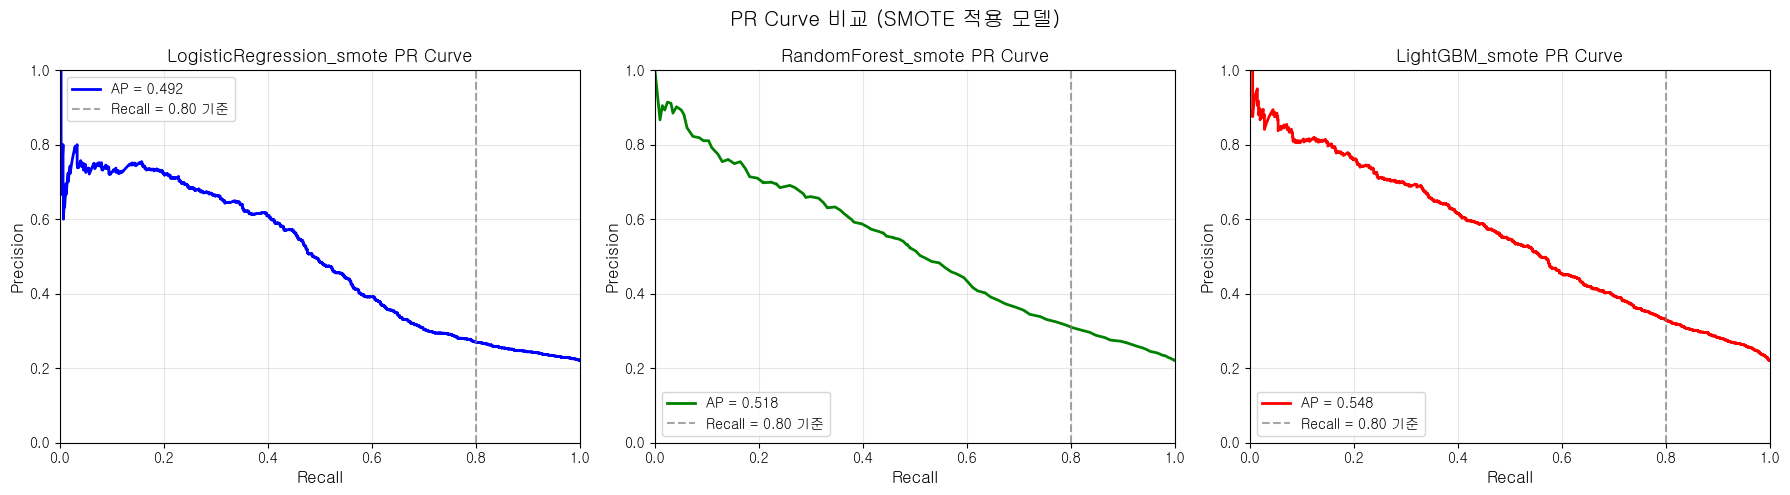

In [38]:
# 임계값(Threshold) 조정
# 핵심 개념:
# - 기본 threshold = 0.5 → 확률이 50% 이상이면 채무불이행으로 분류
# - threshold를 낮추면 → Recall ↑, Precision ↓
# - threshold를 높이면 → Recall ↓, Precision ↑
# 실험 목표: Recall >= 0.80 조건에서 Precision 최대인 최적 threshold 탐색

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

# SMOTE 모델 3개의 예측 확률 저장 (마지막 루프 = smote 학습 모델)
smote_probas = {}
for model_name, model in models.items():
    smote_probas[model_name] = model.predict_proba(X_test_scaled)[:, 1]

# PR Curve 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_configs = [
    ('LogisticRegression', 'blue'),
    ('RandomForest',       'green'),
    ('LightGBM',           'red'),
]

for ax, (model_name, color) in zip(axes, model_configs):
    y_proba = smote_probas[model_name]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)

    ax.plot(recall, precision, color=color, lw=2, label=f'AP = {ap:.3f}')
    ax.axvline(x=0.80, color='gray', linestyle='--', alpha=0.7, label='Recall = 0.80 기준')

    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'{model_name}_smote PR Curve', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

plt.suptitle('PR Curve 비교 (SMOTE 적용 모델)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

# LightGBM_smote 기준으로 임계값별 성능 변화 확인
y_proba_lgbm = smote_probas['LightGBM']

thresholds_to_try = np.arange(0.1, 0.65, 0.05)
threshold_results = []

for thresh in thresholds_to_try:
    y_pred_t = (y_proba_lgbm >= thresh).astype(int)
    threshold_results.append({
        'Threshold' : round(thresh, 2),
        'Recall'    : round(recall_score(y_test, y_pred_t), 4),
        'Precision' : round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'F1'        : round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'Accuracy'  : round(accuracy_score(y_test, y_pred_t), 4),
    })

thresh_df = pd.DataFrame(threshold_results)
print("=== LightGBM_smote: 임계값별 성능 변화 ===")
print(thresh_df.to_string(index=False))

=== LightGBM_smote: 임계값별 성능 변화 ===
 Threshold  Recall  Precision     F1  Accuracy
      0.10  0.9676     0.2529 0.4009    0.3605
      0.15  0.8907     0.2868 0.4339    0.4860
      0.20  0.7995     0.3299 0.4671    0.5965
      0.25  0.7234     0.3796 0.4979    0.6773
      0.30  0.6375     0.4312 0.5144    0.7338
      0.35  0.5765     0.4793 0.5234    0.7678
      0.40  0.5252     0.5284 0.5268    0.7913
      0.45  0.4770     0.5632 0.5165    0.8025
      0.50  0.4258     0.5947 0.4963    0.8088
      0.55  0.3836     0.6355 0.4784    0.8150
      0.60  0.3497     0.6554 0.4560    0.8155


In [41]:
# 최적 임계값 탐색: Recall >= 0.80 조건에서 Precision 최대
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_proba_lgbm)

# precision_recall_curve: threshold 오름차순 → recall 내림차순
# 마지막 원소는 threshold 없음 → [:-1]로 길이 맞춤
recall_min = 0.80
valid_mask = recall_arr[:-1] >= recall_min

if valid_mask.any():
    best_idx       = np.argmax(precision_arr[:-1][valid_mask])
    best_threshold = thresholds_arr[valid_mask][best_idx]
    best_precision = precision_arr[:-1][valid_mask][best_idx]
    best_recall    = recall_arr[:-1][valid_mask][best_idx]

    print(f"[ Recall >= {recall_min} 조건에서 최적 Threshold ]")
    print(f"  최적 Threshold : {best_threshold:.4f}")
    print(f"  → Recall       : {best_recall:.4f}")
    print(f"  → Precision    : {best_precision:.4f}")
else:
    print(f"Recall >= {recall_min} 조건을 만족하는 threshold가 없습니다.")

[ Recall >= 0.8 조건에서 최적 Threshold ]
  최적 Threshold : 0.1998
  → Recall       : 0.8011
  → Precision    : 0.3301


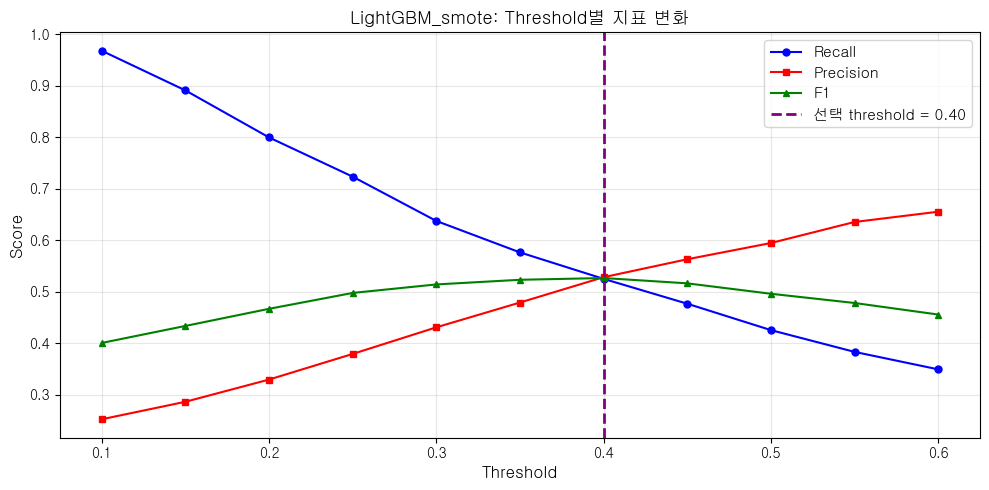

In [43]:
# Threshold별 지표 변화 라인차트
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    'b-o', label='Recall',    markersize=5)
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 'r-s', label='Precision', markersize=5)
ax.plot(thresh_df['Threshold'], thresh_df['F1'],        'g-^', label='F1',        markersize=5)

ax.axvline(x=0.40, color='purple', linestyle='--', lw=2, label='선택 threshold = 0.40')

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('LightGBM_smote: Threshold별 지표 변화', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# threshold=0.40 적용 후 성능 평가
best_threshold = 0.40
y_pred_optimal = (y_proba_lgbm >= best_threshold).astype(int)

result_optimal = get_clf_eval(
    y_test, y_pred_optimal, y_proba_lgbm,
    model_name='LightGBM_smote (threshold=0.40)'
)
results.append(result_optimal)

=== [LightGBM_smote (threshold=0.40)] 성능 평가 ===
혼동행렬:
  TN=  4051  FP=   622
  FN=   630  TP=   697

  ★ Recall   : 0.5252
     F1      : 0.5268
     ROC-AUC : 0.7694
     Accuracy: 0.7913
     Precision:0.5284


In [45]:
# threshold=0.5(기본) vs threshold=0.40 비교 테이블
compare = pd.DataFrame([r for r in results if 'LightGBM_smote' in r['Model']])
compare = compare.set_index('Model')
print("=== LightGBM_smote threshold 조정 전후 비교 ===")
compare

=== LightGBM_smote threshold 조정 전후 비교 ===


,Recall,F1,ROC-AUC,Accuracy,Precision
Model,,,,,
LightGBM_smote,0.4258,0.4963,0.7694,0.8088,0.5947
LightGBM_smote (threshold=0.40),0.5252,0.5268,0.7694,0.7913,0.5284


# 피처 엔지니어링

## 추가할 피처
| 그룹 | 변수 | 계산 방법 |
|---|---|---|
| 연체 관련 | MAX_DELAY | PAY_0~6 최대값 |
| 연체 관련 | DELAY_COUNT | PAY >= 1 인 달 수 |
| 연체 관련 | RECENT_DELAY | PAY_0, PAY_2 평균 |
| 한도 활용률 | UTIL_RATE | BILL_AMT1 / LIMIT_BAL |
| 잔액 추이 | BILL_TREND | BILL_AMT1 - BILL_AMT6 |

In [46]:
# 원본 피처에 새 피처 추가 (원본 card_df 복사 후 작업)
card_fe = card_df.copy()

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# 1. 연체 관련
card_fe['MAX_DELAY']    = card_fe[pay_cols].max(axis=1)                        # 최대 연체 개월 수
card_fe['DELAY_COUNT']  = (card_fe[pay_cols] >= 1).sum(axis=1)                 # 연체(1개월+) 달 수
card_fe['RECENT_DELAY'] = card_fe[['PAY_0', 'PAY_2']].mean(axis=1)            # 최근 2개월 연체 평균

# 2. 한도 활용률
card_fe['UTIL_RATE']    = card_fe['BILL_AMT1'] / (card_fe['LIMIT_BAL'] + 1)   # 최근 청구 / 한도

# 3. 잔액 추이
card_fe['BILL_TREND']   = card_fe['BILL_AMT1'] - card_fe['BILL_AMT6']         # 청구금액 증가 추세

print("=== 추가된 피처 확인 ===")
new_cols = ['MAX_DELAY', 'DELAY_COUNT', 'RECENT_DELAY', 'UTIL_RATE', 'BILL_TREND']
print(card_fe[new_cols].describe().round(3))

=== 추가된 피처 확인 ===
       MAX_DELAY  DELAY_COUNT  RECENT_DELAY  UTIL_RATE  BILL_TREND
count  30000.000    30000.000     30000.000  30000.000   30000.000
mean       0.439        0.834        -0.075      0.424   12351.570
std        1.345        1.554         1.061      0.411   43922.422
min       -2.000        0.000        -2.000     -0.620 -428791.000
25%        0.000        0.000        -0.500      0.022   -2963.000
50%        0.000        0.000         0.000      0.314     923.000
75%        2.000        1.000         0.000      0.830   19793.750
max        8.000        6.000         7.500      6.455  708323.000


In [48]:
# 새 피처와 default 상관관계 확인
new_corr = card_fe[new_cols + ['default']].corr()['default'].drop('default').sort_values(ascending=False)
print("=== 새 피처와 default 상관관계 ===")
print(new_corr.round(4))

=== 새 피처와 default 상관관계 ===
DELAY_COUNT     0.3984
MAX_DELAY       0.3310
RECENT_DELAY    0.3206
UTIL_RATE       0.0862
BILL_TREND     -0.0256
Name: default, dtype: float64


In [49]:
# train/test split (피처 엔지니어링 적용 데이터)
y_fe = card_fe['default']
X_fe = card_fe.drop('default', axis=1)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

# 스케일링
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled  = scaler_fe.transform(X_test_fe)

# SMOTE
X_train_fe_smote, y_train_fe_smote = smote.fit_resample(X_train_fe_scaled, y_train_fe)

print(f"피처 수: {X_fe.shape[1]}개 (원본 23개 → 새 피처 5개 추가)")
print(f"SMOTE 후 학습 데이터: {X_train_fe_smote.shape}")

피처 수: 28개 (원본 23개 → 새 피처 5개 추가)
SMOTE 후 학습 데이터: (37382, 28)


In [50]:
# LightGBM + 피처 엔지니어링 + threshold=0.40 평가
lgbm_fe = LGBMClassifier(n_estimators=100, random_state=42)
lgbm_fe.fit(X_train_fe_smote, y_train_fe_smote)

y_proba_fe = lgbm_fe.predict_proba(X_test_fe_scaled)[:, 1]
y_pred_fe  = (y_proba_fe >= 0.40).astype(int)

result_fe = get_clf_eval(y_test_fe, y_pred_fe, y_proba_fe,
                         model_name='LightGBM_smote_FE (threshold=0.40)')
results.append(result_fe)

[LightGBM] [Info] Number of positive: 18691, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001651 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6961
[LightGBM] [Info] Number of data points in the train set: 37382, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
=== [LightGBM_smote_FE (threshold=0.40)] 성능 평가 ===
혼동행렬:
  TN=  4021  FP=   652
  FN=   616  TP=   711

  ★ Recall   : 0.5358
     F1      : 0.5286
     ROC-AUC : 0.7747
     Accuracy: 0.7887
     Precision:0.5216


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [51]:
# 피처 엔지니어링 전후 비교 (threshold=0.40 기준)
compare_fe = pd.DataFrame([
    r for r in results
    if r['Model'] in ['LightGBM_smote (threshold=0.40)', 'LightGBM_smote_FE (threshold=0.40)']
]).set_index('Model')

print("=== 피처 엔지니어링 전후 비교 (threshold=0.40) ===")
compare_fe

=== 피처 엔지니어링 전후 비교 (threshold=0.40) ===


,Recall,F1,ROC-AUC,Accuracy,Precision
Model,,,,,
LightGBM_smote (threshold=0.40),0.5252,0.5268,0.7694,0.7913,0.5284
LightGBM_smote_FE (threshold=0.40),0.5358,0.5286,0.7747,0.7887,0.5216


# 